# Performance

Two things make this library fast, and they are worth knowing in order of importance: **pass arrays instead of looping**, which costs nothing and wins the most, and **the compiled backend**, which since 1.13.0 is installed with the package and needs nothing asked of it.

Every number below is measured when the notebook runs, so it reflects the machine that produced this copy rather than a figure carried over from a README.

In [1]:
import sys
import os

# Works whether or not the package is installed: these notebooks sit one
# level below the repository root, so src/ is one directory up.
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))

import numpy as np
import matplotlib.pyplot as plt

import globaldefs as gd
import oscprob2nu
import oscprob3nu
import oscprob4nu
import hamiltonians2nu
import hamiltonians3nu
import hamiltonians4nu

%matplotlib inline
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 90,
                     'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 11, 'legend.frameon': False,
                     # Axes end exactly at the data: no padding beyond
                     # x_min/x_max or y_min/y_max.
                     'axes.xmargin': 0.0, 'axes.ymargin': 0.0})

# The three-flavor vacuum Hamiltonian at the NuFit best fit, normal ordering.
# It is energy-independent; dividing by the energy is what the builders do.
H_VAC_3NU = hamiltonians3nu.hamiltonian_3nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF, gd.DCP_NO_BF,
    gd.D21_NO_BF, gd.D31_NO_BF)

KM = gd.CONV_KM_TO_INV_EV      # multiply a length in km to get eV^-1
GEV = 1.0e9                    # multiply an energy in GeV to get eV

In [2]:
# Every timing in this notebook, and every timing quoted in the paper,
# was measured on one laptop:
#
#     Intel Core i5-1334U, 10 cores / 12 threads, up to 4.6 GHz
#     16 GB RAM
#     Ubuntu 24.04.4 LTS, kernel 7.0.0-28-generic
#     Python 3.12.7, numpy 1.26.4, numba 0.60.0, gcc 13.3
#
# Absolute times mean little without that, and would be perhaps a factor
# of two different on a workstation.  The ratios between routes, which is
# what these cells are actually about, are far more stable than the
# absolute numbers and are what the text quotes.
import time

import fastkernels


def best_of(func, repeat=5):
    """Returns the fastest of `repeat` runs, in seconds.

    The minimum, not the mean: timing noise is one-sided, so
    the fastest run is the one least polluted by whatever else
    the machine was doing.
    """
    best = float("inf")
    for _ in range(repeat):
        t0 = time.perf_counter()
        func()
        best = min(best, time.perf_counter()-t0)
    return best


print("Numba available:", fastkernels.HAVE_NUMBA)

Numba available: True


## Looping versus broadcasting

The same energy scan, done both ways. The batched call is one invocation; the loop is one per point.

In [3]:
n_points = 2000
E_gev = np.logspace(-1.0, 1.5, n_points)
L = 1300.0*KM

H_stack = hamiltonians3nu.hamiltonian_3nu_matter(
    H_VAC_3NU, E_gev*GEV, gd.VCC_EARTH_CRUST)


def batched():
    return oscprob3nu.probabilities_3nu(H_stack, L)


def looped():
    return [oscprob3nu.probabilities_3nu(h, L) for h in H_stack]


t_batch = best_of(batched)
t_loop = best_of(looped, repeat=3)

print("loop over %d points : %8.2f ms" % (n_points, t_loop*1e3))
print("one batched call   : %8.2f ms" % (t_batch*1e3))
print("speedup            : %8.1fx" % (t_loop/t_batch))

loop over 2000 points :    26.42 ms
one batched call   :     0.32 ms
speedup            :     82.7x


The two agree to round-off — the same arithmetic, organised differently. Not *bit for bit*: the batched path sums and multiplies in a different order, and floating-point addition is not associative, so the last digit or two can differ. The number below is the honest measure of that.

In [4]:
print("max |batched - looped| = %.2e"
      % np.max(np.abs(np.array(batched()) - np.array(looped()))))

max |batched - looped| = 8.21e-14


## How the gain scales

The advantage grows with the size of the scan, because the fixed cost of a batched call is amortised over more points. Below a handful of elements the library detects this and takes the scalar path instead — that is what `oscprob3nu.SMALL_BATCH` is for.

In [5]:
sizes = [1, 3, 10, 30, 100, 300, 1000, 3000, 10000]
rows = []
for n in sizes:
    E = np.logspace(-1.0, 1.5, n)
    Hs = hamiltonians3nu.hamiltonian_3nu_matter(
        H_VAC_3NU, E*GEV, gd.VCC_EARTH_CRUST)
    tb = best_of(lambda: oscprob3nu.probabilities_3nu(Hs, L))
    tl = best_of(lambda: [oscprob3nu.probabilities_3nu(h, L)
                          for h in Hs], repeat=3)
    rows.append((n, tl, tb))

rows = np.array(rows)
print("%8s %12s %12s %9s" % ("N", "loop [ms]", "batched [ms]",
                            "speedup"))
for n, tl, tb in rows:
    print("%8d %12.3f %12.3f %8.1fx" % (n, tl*1e3, tb*1e3, tl/tb))

       N    loop [ms] batched [ms]   speedup
       1        0.020        0.057      0.3x
       3        0.049        0.058      0.8x
      10        0.154        0.054      2.9x
      30        0.416        0.058      7.2x
     100        1.370        0.070     19.6x
     300        4.105        0.084     48.7x
    1000       13.570        0.137     98.9x
    3000       41.428        0.268    154.4x
   10000      139.081        0.631    220.5x


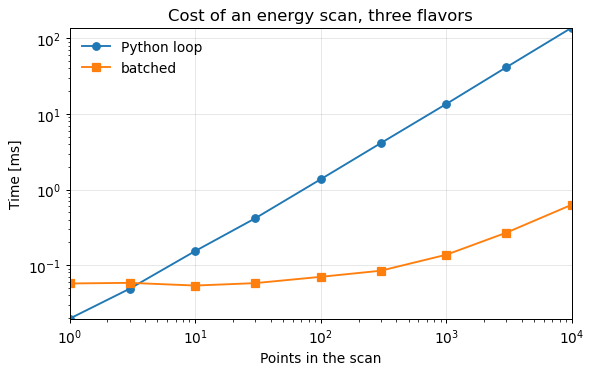

In [6]:
fig, ax = plt.subplots()
ax.loglog(rows[:, 0], rows[:, 1]*1e3, "o-", label="Python loop")
ax.loglog(rows[:, 0], rows[:, 2]*1e3, "s-", label="batched")
ax.set_xlim(rows[0, 0], rows[-1, 0])
ax.set_xlabel("Points in the scan")
ax.set_ylabel("Time [ms]")
ax.set_title("Cost of an energy scan, three flavors")
ax.legend()
plt.show()

## The compiled backend

`numba` comes with the package as of 1.13.0, so the batched paths hand large stacks to a compiled kernel without anything being installed on purpose. It is switchable at runtime, which is how the regression suite checks the two paths against each other — and is what makes the comparison below possible in one process.

In [7]:
if not fastkernels.HAVE_NUMBA:
    print("numba is not installed; skipping this comparison.")
else:
    n = 200000
    E = np.logspace(-1.0, 1.5, n)
    Hs = hamiltonians3nu.hamiltonian_3nu_matter(
        H_VAC_3NU, E*GEV, gd.VCC_EARTH_CRUST)

    # Warm the cache: the first call compiles.
    oscprob3nu.probabilities_3nu(Hs[:100], L)

    fastkernels.USE_NUMBA = True
    t_kernel = best_of(lambda: oscprob3nu.probabilities_3nu(Hs, L))
    fastkernels.USE_NUMBA = False
    t_numpy = best_of(lambda: oscprob3nu.probabilities_3nu(Hs, L))
    fastkernels.USE_NUMBA = True

    print("%d energies, three flavors" % n)
    print("  NumPy path     : %8.1f ms" % (t_numpy*1e3))
    print("  compiled kernel: %8.1f ms" % (t_kernel*1e3))
    print("  speedup        : %8.1fx" % (t_numpy/t_kernel))

200000 energies, three flavors
  NumPy path     :    147.2 ms
  compiled kernel:     11.1 ms
  speedup        :     13.3x


The two paths agree to round-off, which is the property that makes the backend safe to install and forget about:

In [8]:
if fastkernels.HAVE_NUMBA:
    Hs = hamiltonians3nu.hamiltonian_3nu_matter(
        H_VAC_3NU, np.logspace(-1, 1.5, 5000)*GEV,
        gd.VCC_EARTH_CRUST)
    fastkernels.USE_NUMBA = True
    a = np.array(oscprob3nu.probabilities_3nu(Hs, L))
    fastkernels.USE_NUMBA = False
    b = np.array(oscprob3nu.probabilities_3nu(Hs, L))
    fastkernels.USE_NUMBA = True
    print("max |kernel - numpy| = %.2e" % np.max(np.abs(a-b)))

max |kernel - numpy| = 2.78e-15


## Where the backend does *not* help

The two-flavor expansion reduces to a square root and a sine per element, which NumPy already does about as well as compiled code can. The library therefore declines the kernel below a measured threshold rather than using it everywhere — a backend that is sometimes slower than the path it replaces is worse than no backend.

In [9]:
print("thresholds at which the compiled kernel is used:")
for n_flavors, threshold in sorted(fastkernels.MIN_BATCH.items()):
    print("  %d flavors: stacks of %d or more"
          % (n_flavors, threshold))
print()
print("below these sizes the NumPy path is used, whether or "
      "not numba is installed")

thresholds at which the compiled kernel is used:
  2 flavors: stacks of 50000 or more
  3 flavors: stacks of 1 or more
  4 flavors: stacks of 1 or more

below these sizes the NumPy path is used, whether or not numba is installed


## Four flavors cost more

`oscprob4nu` broadcasts exactly like its three-flavor sibling, but two things make it dearer per element.

1. **More algebra.** Fifteen generators rather than eight, a quartic characteristic equation rather than a cubic.
2. **The root strategy.** `oscprob4nu.ROOT_STRATEGY` defaults to `'double-double'`, which is what keeps a stiff 3+1 spectrum accurate and costs roughly a fifth more than the eigensolver route behind it.

Both flavor counts have a compiled kernel, so the ratio is measured twice below: once with both paths on NumPy and once with both compiled. Taking it across the two — four-flavor NumPy against three-flavor Numba — would blame the algebra for a difference in backend, which is the mistake this section had to warn about while four flavors had no kernel.

In [10]:
H4_VAC = hamiltonians4nu.hamiltonian_4nu_vacuum_energy_independent(
    gd.S12_NO_BF, gd.S23_NO_BF, gd.S13_NO_BF,
    np.sqrt(0.10), np.sqrt(0.10), 0.0,
    gd.DCP_NO_BF, gd.D21_NO_BF, gd.D31_NO_BF, 1.0)

n4 = 20000
E4 = np.logspace(-1.0, 1.5, n4)*GEV
H4 = hamiltonians4nu.hamiltonian_4nu_matter(
    H4_VAC, E4, gd.VCC_EARTH_CRUST, gd.VNC_EARTH_CRUST)
H3 = hamiltonians3nu.hamiltonian_3nu_matter(
    H_VAC_3NU, E4, gd.VCC_EARTH_CRUST)

# Warm both paths before timing either
oscprob3nu.probabilities_3nu(H3, L)
oscprob4nu.probabilities_4nu(H4, L)

fastkernels.USE_NUMBA = True
t3_numba = best_of(lambda: oscprob3nu.probabilities_3nu(H3, L))
t4_numba = best_of(lambda: oscprob4nu.probabilities_4nu(H4, L))
fastkernels.USE_NUMBA = False
t3_numpy = best_of(lambda: oscprob3nu.probabilities_3nu(H3, L))
t4 = best_of(lambda: oscprob4nu.probabilities_4nu(H4, L))
oscprob4nu.POLISH_ROOTS = False
t4_raw = best_of(lambda: oscprob4nu.probabilities_4nu(H4, L))
oscprob4nu.POLISH_ROOTS = True
fastkernels.USE_NUMBA = True

print("%d energies" % n4)
print("  3 flavors, NumPy path      : %7.1f ms" % (t3_numpy*1e3))
print("  4 flavors, NumPy, polished : %7.1f ms" % (t4*1e3))
print("  4 flavors, NumPy, no polish: %7.1f ms" % (t4_raw*1e3))
print("  3 flavors, compiled kernel : %7.1f ms" % (t3_numba*1e3))
print("  4 flavors, compiled kernel : %7.1f ms" % (t4_numba*1e3))
print("\n  4nu / 3nu, both on NumPy   : %.1fx" % (t4/t3_numpy))
print("  4nu / 3nu, both compiled   : %.1fx" % (t4_numba/t3_numba))
print("  what the kernel buys at 4nu: %.1fx" % (t4/t4_numba))
print("  the refinement is           : %.0f%% of the "
      "four-flavor NumPy call" % (100*(t4-t4_raw)/t4))

20000 energies
  3 flavors, NumPy path      :     7.0 ms
  4 flavors, NumPy, polished :   133.0 ms
  4 flavors, NumPy, no polish:   127.1 ms
  3 flavors, compiled kernel :     1.0 ms
  4 flavors, compiled kernel :    12.3 ms

  4nu / 3nu, both on NumPy   : 18.9x
  4nu / 3nu, both compiled   : 12.5x
  what the kernel buys at 4nu: 10.9x
  the refinement is           : 4% of the four-flavor NumPy call


So four flavors costs several times three on the NumPy path — the algebra and the refinement — but noticeably less than that once both are compiled. That is not the algebra getting cheaper: a good part of the four-flavor penalty was never algebra at all but the fixed cost of driving it as forty whole-array passes, a batched determinant and a Newton step among them, and the kernel does not pay that cost.

Switching the refinement off buys back roughly a third of the NumPy call and gives up a factor of two on the roots. Changing `ROOT_STRATEGY` away from its default gives up rather more — an order of magnitude — for roughly a fifth of the time. Notebook 16 measures both against a fifty-digit oracle, and is also where the catch lives: on a stiff spectrum neither choice is visible in the *probabilities*, because the accumulated phase dominates them.

## What a tolerance costs

`rtol` and `atol` are an accuracy feature rather than a speed one, but they have a cost worth knowing. The search evaluates the chord at a doubling sequence of subdivisions, which comes to roughly twice one evaluation at the subdivision it settles on — the series being dominated by its last term. Called once for a scan that is nothing. Called per point, it is paid at every point.

In [11]:
import earth

E_scan = np.logspace(0.0, 2.0, 200)*GEV
atol = 1.0e-5

n = earth.slabs_for_tolerance(H_VAC_3NU, E_scan, -0.8, atol=atol)
t_search = best_of(lambda: earth.slabs_for_tolerance(
    H_VAC_3NU, E_scan, -0.8, atol=atol), repeat=3)
t_scan = best_of(lambda: earth.probabilities_3nu_earth(
    H_VAC_3NU, E_scan, -0.8, n))

# The trap, on a tenth of the points so the notebook still finishes.
sample = E_scan[:20]
t_each = best_of(lambda: [earth.probabilities_3nu_earth(
    H_VAC_3NU, e, -0.8, atol=atol) for e in sample], repeat=2)

print("subdivision chosen           : %d" % n)
print("search, once for the scan    : %7.1f ms" % (t_search*1e3))
print("the scan itself, at that n   : %7.1f ms" % (t_scan*1e3))
print("together                     : %7.1f ms"
      % ((t_search+t_scan)*1e3))
print("per point, scaled to 200     : %7.1f ms"
      % (t_each*1e3*len(E_scan)/len(sample)))

subdivision chosen           : 256
search, once for the scan    :    26.7 ms
the scan itself, at that n   :    13.4 ms
together                     :    40.0 ms
per point, scaled to 200     :   140.7 ms


## What the palindrome is worth

A neutrino crossing a spherically symmetric Earth meets every radius on the way in and again on the way out, so slab $j$ and slab $n-1-j$ carry the same Hamiltonian, the same width, and therefore the same operator. Composing from the centre outwards computes each of them once instead of twice.

It is on by default and needs nothing from the caller. It is switchable because the two orderings round differently — by a few times $10^{-15}$ — so turning it off is how to ask for the plain left-to-right product when a comparison needs one.

In [12]:
E_long = np.logspace(0.0, 2.0, 2000)*GEV

fastkernels.USE_PALINDROME = True
t_on = best_of(lambda: earth.probabilities_3nu_earth(
    H_VAC_3NU, E_long, -0.8))
with_it = earth.probabilities_3nu_earth(H_VAC_3NU, E_long, -0.8)

fastkernels.USE_PALINDROME = False
t_off = best_of(lambda: earth.probabilities_3nu_earth(
    H_VAC_3NU, E_long, -0.8))
without = earth.probabilities_3nu_earth(H_VAC_3NU, E_long, -0.8)

fastkernels.USE_PALINDROME = True     # back to the default

print("2000-energy Earth scan, three flavors")
print("  composing the whole chord : %7.2f ms" % (t_off*1e3))
print("  using the palindrome      : %7.2f ms" % (t_on*1e3))
print("  speedup                   : %7.2fx" % (t_off/t_on))
print("  largest difference        : %.2e"
      % np.max(np.abs(with_it-without)))

2000-energy Earth scan, three flavors
  composing the whole chord :    9.81 ms
  using the palindrome      :    4.88 ms
  speedup                   :    2.01x
  largest difference        : 4.88e-15


## What to take away

1. Replace loops with array arguments. This is the large win, it needs no extra dependency, and the results agree to round-off.
2. The compiled backend needs nothing installed — `numba` is a dependency as of 1.13.0. It is used at three and four flavors, and declined at two, where NumPy is already as quick.
3. Do not bother for a handful of points: the library already takes the quicker path there on its own.
4. At four flavors, expect several times the per-element cost of three — and leave `POLISH_ROOTS` alone unless you have measured that you can afford not to.

---

**Previous:** [Unusual density profiles](08_unusual_density_profiles.ipynb)  
**Next:** [The paper's figures](10_paper_figures.ipynb) --- the two figures of arXiv:1904.12391, reproduced  
[API reference](https://mbustama.github.io/NuOscProbExact/functions.html) &middot; [Numerical recipes](https://mbustama.github.io/NuOscProbExact/recipes.html) &middot; [All notebooks](.)